# Régularisation de Tikhonov — Cas 1

On étudie l'effet du paramètre de régularisation $\lambda$ sur l'erreur d'estimation
$\hat\varepsilon_n(\sigma)$. Le M-step régularisé résout :

$$\bigl(M^{(k)} + \lambda\sigma^2 I\bigr)\,\theta^{(k+1)} = b^{(k)}$$

au lieu de $M^{(k)}\theta^{(k+1)} = b^{(k)}$. Le terme $\lambda\sigma^2 I$ stabilise
l'inversion lorsque $M^{(k)}$ est mal conditionné (Cas 2) ou pour réduire la variance
en régime peu de données.

On s'attend à une erreur minimale pour un $\lambda$ intermédiaire : trop petit,
la variance domine ; trop grand, le biais domine.

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

np.random.seed(43)

In [68]:
# --- Parametres ---
n     = 50         # nombre d'observations
p     = 32         # points sur la grille spatiale
N     = 3          # nombre de frequences
d     = 2*N + 1    # dimension de u
sigma = 0.3        # ecart-type du bruit
n_z   = 50         # points de quadrature (réduit pour la vitesse)

xgrid = np.linspace(0, 2*np.pi, p,   endpoint=False)
zgrid = np.linspace(0, 2*np.pi, n_z, endpoint=False)
dz    = 2*np.pi / n_z

# Vrai parametre inconnu (a retrouver)
u_true = np.random.randn(d)

# Decalages Z_i uniformes
Z = np.random.uniform(0, 2*np.pi, n)

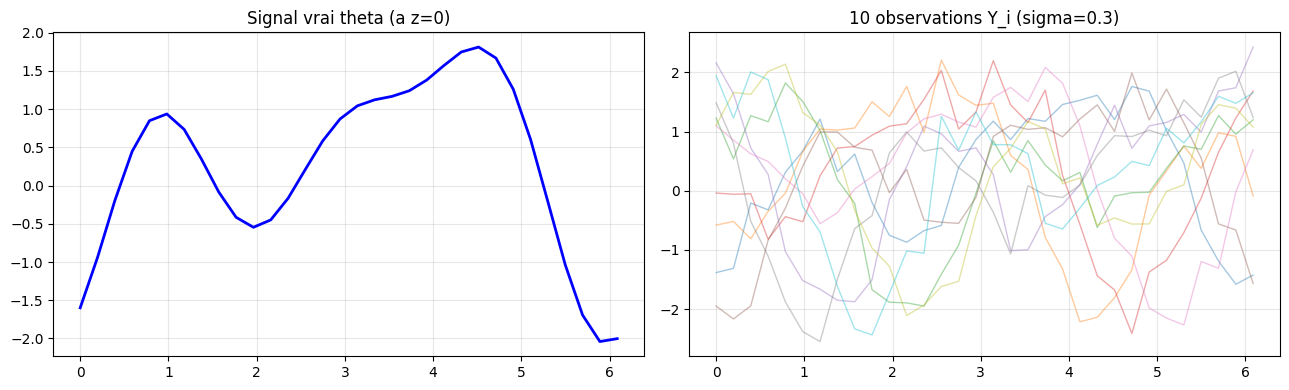

Phi_stack : (50, 32, 7)   PhiTPhi_stack : (50, 7, 7)


In [69]:
def build_phi(z):
    """Matrice Phi(z) de taille (p, d). Phi(z) @ u = signal theta_u translate de z."""
    phi = np.zeros((p, d))
    phi[:, 0] = 1.0
    for k in range(1, N + 1):
        phi[:, 2*k - 1] = np.cos(k * (xgrid - z))
        phi[:, 2*k]     = np.sin(k * (xgrid - z))
    return phi  # (p, d)


def build_phiu(z, u):
    """Signal theta_u sur la grille, pour le decalage z. Retourne (p,)."""
    return build_phi(z) @ u


# --- Observations : Y_i = Phi(Z_i) u_true + sigma * bruit ---
signals      = np.array([build_phiu(z=zi, u=u_true) for zi in Z])  # (n, p)
observations = signals + sigma * np.random.randn(n, p)             # (n, p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(xgrid, build_phiu(z=0, u=u_true), 'b-', lw=2)
ax1.set_title('Signal vrai theta (a z=0)'); ax1.grid(alpha=0.3)
for i in range(min(n, 10)):
    ax2.plot(xgrid, observations[i], alpha=0.4, lw=1)
ax2.set_title(f'{min(n,10)} observations Y_i (sigma={sigma})')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Précalcul une fois pour toutes (vectorisation du E/M-step)
Phi_stack     = np.array([build_phi(z) for z in zgrid])          # (n_z, p, d)
PhiTPhi_stack = np.einsum('qpi,qpj->qij', Phi_stack, Phi_stack)  # (n_z, d, d)
print(f'Phi_stack : {Phi_stack.shape}   PhiTPhi_stack : {PhiTPhi_stack.shape}')

In [70]:
# Seuil de clipping : exp(-QI_MAX) est indiscernable de 0 en float64
QI_MAX = 745.0


def qi(z, y, u):
    """(1/2sigma^2) * ||y - Phi(z)u||^2, clippe a QI_MAX."""
    residual = y - build_phiu(z=z, u=u)              # (p,)
    sq_norm  = float(np.dot(residual, residual))
    return min(sq_norm / (2.0 * sigma**2), QI_MAX)


def log_likelihood(u):
    """
    Log-vraisemblance observee, approchee par quadrature :
        l_n(u) = C + sum_i log( dz * sum_q exp(-qi(z_q, yi, u)) ).
    Utilise logsumexp pour eviter les NaN.
    """
    C  = -0.5 * n * p * np.log(2*np.pi*sigma**2) - n * np.log(2*np.pi)
    ll = C
    for yi in observations:
        log_w = np.array([-qi(z=z, y=yi, u=u) for z in zgrid])  # (n_z,)
        ll += np.log(dz) + logsumexp(log_w)
    return ll

## Algorithme EM régularisé

Les fonctions ci-dessous sont entièrement vectorisées (pas de boucle Python sur
$n \times n_z$) grâce au précalcul de `Phi_stack` et `PhiTPhi_stack`.

`em_reg` retourne l'historique de la log-vraisemblance à chaque itération :
la propriété fondamentale de l'EM garantit que cette suite est croissante,
ce qui est vérifié dans la section suivante.

In [71]:
def e_step(u, obs):
    """
    Etape E vectorisée : poids a posteriori w_{i,z_q}(u), shape (n, n_z).
    Residuals calculés en broadcast (n, n_z, p) sans boucle Python.
    """
    Amu       = Phi_stack @ u                                      # (n_z, p)
    residuals = obs[:, np.newaxis, :] - Amu[np.newaxis]           # (n, n_z, p)
    log_w     = -0.5 / sigma**2 * np.sum(residuals**2, axis=2)    # (n, n_z)
    log_w     = np.clip(log_w, -745.0, None)
    log_w    -= log_w.max(axis=1, keepdims=True)
    w         = np.exp(log_w)
    return w / w.sum(axis=1, keepdims=True)                        # (n, n_z)


def m_step_reg(weights, lam, obs):
    """
    Etape M régularisée (Tikhonov) : résout (M + λσ²I)u = b.
        M = sum_{i,q} w_{i,q} Phi(z_q)^T Phi(z_q)   [via PhiTPhi_stack]
        b = sum_{i,q} w_{i,q} Phi(z_q)^T Y_i         [via einsum]
    """
    w_sum_i = weights.sum(axis=0)                                  # (n_z,)
    M_mat   = np.einsum('q,qij->ij', w_sum_i, PhiTPhi_stack)      # (d, d)
    wY      = np.einsum('iq,ip->qp', weights, obs)                 # (n_z, p)
    b_vec   = np.einsum('qpi,qp->i', Phi_stack, wY)               # (d,)
    M_mat  += lam * sigma**2 * np.eye(d)
    return np.linalg.solve(M_mat, b_vec)


def ll_obs(u, obs):
    """Log-vraisemblance (partie variable) sur un jeu d'observations donné."""
    Amu       = Phi_stack @ u
    residuals = obs[:, np.newaxis, :] - Amu[np.newaxis]           # (n, n_z, p)
    log_terms = np.clip(-0.5 / sigma**2 * np.sum(residuals**2, axis=2), -745, None)
    return float(np.sum(logsumexp(log_terms, axis=1)))


def em_reg(u0, lam, obs, n_iter=80, tol=1e-6):
    """
    EM régularisé depuis u0. Retourne (u_hat, hist_ll).
    hist_ll doit être croissant — propriété fondamentale de l'EM.
    """
    u       = u0.copy()
    hist_ll = [ll_obs(u, obs)]
    for _ in range(n_iter):
        w     = e_step(u, obs)
        u_new = m_step_reg(w, lam, obs)
        hist_ll.append(ll_obs(u_new, obs))
        if np.linalg.norm(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    return u, np.array(hist_ll)

In [72]:
def translation_error(u_hat, u_true, xgrid):
    p = len(xgrid)
    sig_hat  = build_phiu(0, u_hat)
    sig_true = build_phiu(0, u_true)
    corr = np.fft.irfft(
        np.fft.rfft(sig_hat).conj() * np.fft.rfft(sig_true), n=p
    )
    best_shift = np.argmax(corr)
    sig_aligned = np.roll(sig_hat, best_shift)
    return np.linalg.norm(sig_aligned - sig_true) / np.linalg.norm(sig_true)

## Vérification : monotonicité de l'EM régularisé

La log-vraisemblance doit croître à chaque itération (propriété fondamentale de l'EM,
Proposition 4.x du rapport). On vérifie ceci sur un exemple avant de lancer
l'étude en λ.

Gain minimum : +4.202e-09  (doit être ≥ 0)
Itérations   : 21


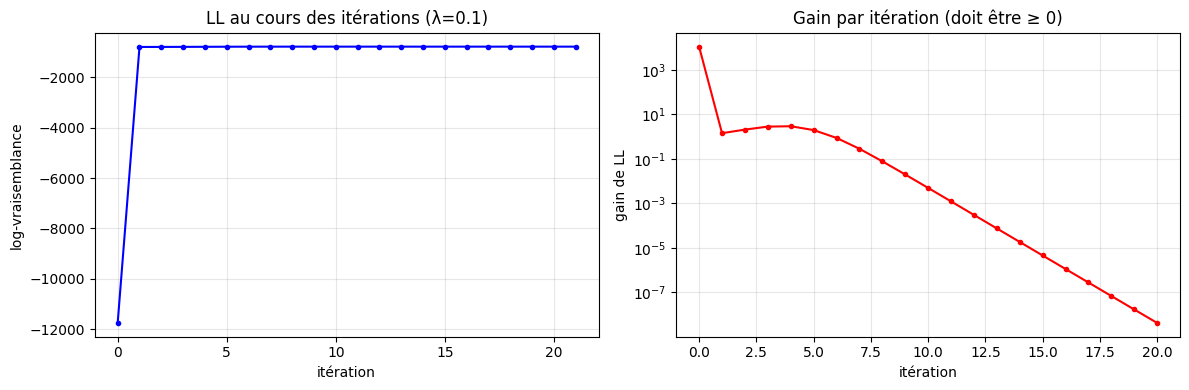

In [73]:
np.random.seed(0)
u0_test = 0.5 * np.random.randn(d)
_, hist_test = em_reg(u0_test, lam=0.1, obs=observations)

gains = np.diff(hist_test)
print(f'Gain minimum : {gains.min():+.3e}  (doit être ≥ 0)')
print(f'Itérations   : {len(hist_test) - 1}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_test, 'b-o', ms=3)
axes[0].set_xlabel('itération'); axes[0].set_ylabel('log-vraisemblance')
axes[0].set_title('LL au cours des itérations (λ=0.1)'); axes[0].grid(alpha=0.3)

axes[1].semilogy(np.maximum(gains, 1e-16), 'r-o', ms=3)
axes[1].set_xlabel('itération'); axes[1].set_ylabel('gain de LL')
axes[1].set_title('Gain par itération (doit être ≥ 0)'); axes[1].grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()

## Étude de l'erreur en fonction de λ

Pour chaque valeur de λ sur une grille log-uniforme, on estime
$\hat\varepsilon_n(\sigma)$ par $M$ répétitions Monte-Carlo indépendantes,
chacune avec un nouveau tirage des observations. La ligne pointillée rouge
indique l'erreur de l'EM non régularisé (λ=0) comme référence.

In [ ]:
lambdas  = np.logspace(-3, 1, 20)
M        = 20
n_starts = 5

errors = np.zeros(len(lambdas))

for j, lam in enumerate(lambdas):
    errs = []
    for m in range(M):
        Z_m   = np.random.uniform(0, 2*np.pi, n)
        obs_m = np.array([build_phiu(z, u_true) for z in Z_m])
        obs_m += sigma * np.random.randn(n, p)

        best_u, best_ll = None, -np.inf
        for _ in range(n_starts):
            u0    = 0.5 * np.random.randn(d)
            u_hat, hist = em_reg(u0, lam, obs=obs_m)
            if hist[-1] > best_ll:
                best_ll, best_u = hist[-1], u_hat

        errs.append(translation_error(best_u, u_true, xgrid))

    errors[j] = np.mean(errs)
    print(f"lam={lam:.4f}  err={errors[j]:.4f}")

# Baseline : EM sans régularisation (lam=0)
errs_nonreg = []
for m in range(M):
    Z_m   = np.random.uniform(0, 2*np.pi, n)
    obs_m = np.array([build_phiu(z, u_true) for z in Z_m])
    obs_m += sigma * np.random.randn(n, p)

    best_u, best_ll = None, -np.inf
    for _ in range(n_starts):
        u0    = 0.5 * np.random.randn(d)
        u_hat, hist = em_reg(u0, lam=0.0, obs=obs_m)
        if hist[-1] > best_ll:
            best_ll, best_u = hist[-1], u_hat

    errs_nonreg.append(translation_error(best_u, u_true, xgrid))

error_em_nonreg = np.mean(errs_nonreg)
print(f"\nErreur EM sans régularisation : {error_em_nonreg:.4f}")

lam=0.0010  err=0.0787
lam=0.0019  err=0.1057
lam=0.0037  err=0.0913
lam=0.0072  err=0.0878
lam=0.0139  err=0.0852
lam=0.0268  err=0.0870
lam=0.0518  err=0.0748
lam=0.1000  err=0.1033
lam=0.1931  err=0.1022
lam=0.3728  err=0.0916
lam=0.7197  err=0.0836
lam=1.3895  err=0.0817
lam=2.6827  err=0.0994
lam=5.1795  err=0.0965
lam=10.0000  err=0.1052

Erreur EM sans régularisation : 0.1104


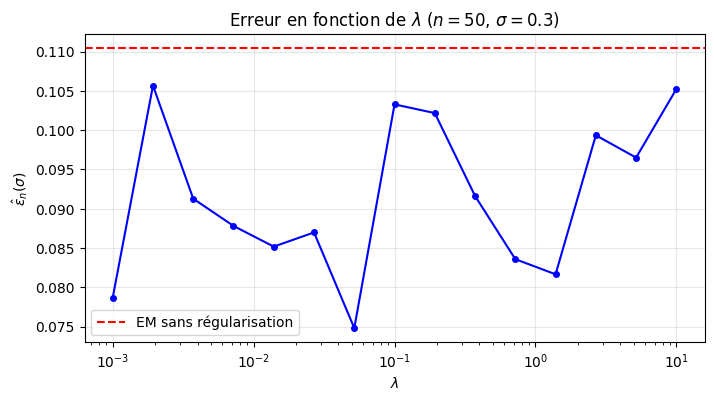

In [79]:
plt.figure(figsize=(8, 4))
plt.semilogx(lambdas, errors, 'b-o', ms=4)
plt.axhline(y=error_em_nonreg, color='r', linestyle='--', 
            label='EM sans régularisation')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\hat{\varepsilon}_n(\sigma)$')
plt.title(r'Erreur en fonction de $\lambda$ ($n=50$, $\sigma=0.3$)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('../figures/erreur_vs_lambda.pdf', bbox_inches='tight')